    Месяц        Дата  p_пласт,МПа  q,тыс.м3/сут  Накопленная,млн м3   
0       1  2025-06-02    25.000000     83.939277            2.554860  \
1       2  2025-07-02    24.680643     83.366802            5.092295   
2       3  2025-08-01    24.052237     82.228698            7.595090   
3       4  2025-09-01    23.138842     80.545795           10.046662   
4       5  2025-10-01    21.976502     78.351972           12.431461   
5       6  2025-11-01    20.610502     75.692568           14.735316   
6       7  2025-12-01    19.091990     72.622074           16.945714   
7       8  2026-01-01    17.474353     69.201484           19.052000   
8       9  2026-01-31    15.809746     65.495409           21.045483   
9      10  2026-03-02    14.146128     61.569147           22.919464   
10     11  2026-04-02    12.525019     50.192229           24.447164   
11     12  2026-05-02    10.994013     37.445554           25.586895   
12     13  2026-06-02     9.587500     23.164497           26.29

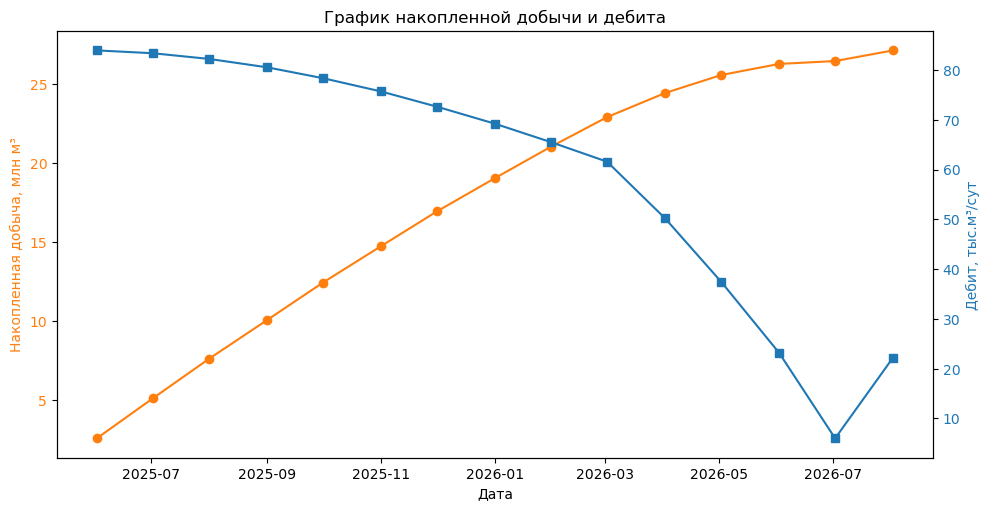

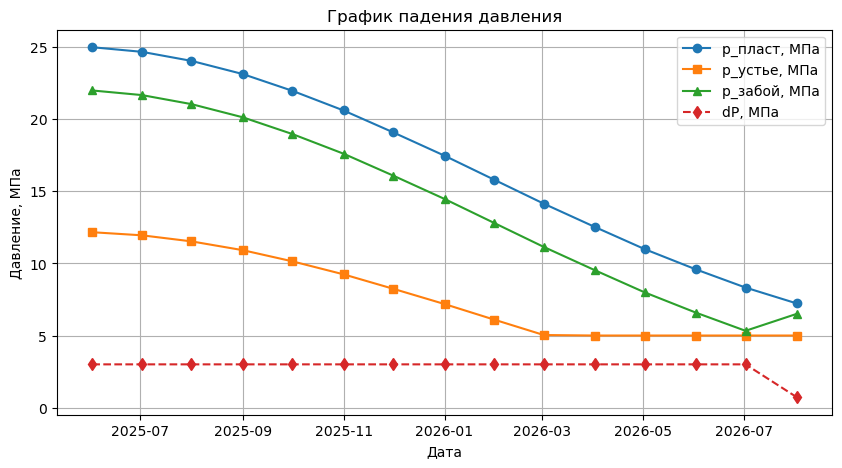

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# =============================================================================
# 1. ВХОДНЫЕ ПАРАМЕТРЫ (точно как в вашем Input-табличке)
# =============================================================================

# Начальное пластовое давление, МПа
p0 = 25.0

# Начальные запасы газа, млн м³ (в усл.ст.) → переводим в м³
Gi_million = 200.0   # млн м³ (ст/усл)
Gi = Gi_million * 1e6  # в реальных м³

# Пластовая температура, K
T = 330.0

# Критическое давление и температура (для расчёта Z-фактора)
Pc = 4.6    # МПа
Tc = 190.6  # K

# IPR (Inflow Performance Relationship) coefficients
a_ipr = 0.001   # МПа²·сут/(тыс.м³)
b_ipr = 0.02    # МПа²·сут²/(тыс.м³)²

# VLP (Vertical Lift Performance) coefficients
c1_vlp = 0.05    # МПа·сут/(тыс.м³)
c2_vlp = 0.0008  # МПа·сут²/(тыс.м³)²

# Условия добычи
dp_max = 3.0       # Макс. депрессия dP = p_plast - p_wf, МПа
pwh_min = 5.0      # Минимальное устьевое давление P_wh, МПа
q_max = 136.99     # Максимальная добыча, тыс.м³/сут

# Горизонт прогноза (в месяцах)
HORIZON_MONTHS = 200

# Дата старта (02.06.2025)
start_date = datetime(2025, 6, 2)

# Среднее число дней в месяце (как в вашем VBA: 30.437)
DAYS_PER_MONTH = 30.437

# =============================================================================
# 2. ФУНКЦИИ ДЛЯ РАСЧЁТА Z-фактора и НОДАЛЬНОГО АНАЛИЗА
# =============================================================================

def z_factor_dpr(P_MPa: float, T_K: float, Pc_MPa: float, Tc_K: float,
                 tol: float = 1e-5, max_iter: int = 50) -> float:
    """
    Расчёт Z-фактора методом Ньютона (Dranchuk и Abou-Kassem).
    P_MPa, T_K           — текущие давление и температура,
    Pc_MPa, Tc_K         — критические давление и температура.
    Возвращает приближённое значение Z.
    """
    # Константы модели Dranchuk-Abou-Kassem
    A1, A2, A3 =  0.31506237, -1.0467099, -0.5783279
    A4, A5, A6 =  0.5353071,  -0.6123203, -0.10488813
    A7, A8, B1 =  0.68157001, 0.68446549, 0.27

    Pr = P_MPa / Pc_MPa
    Tr = T_K / Tc_K
    Z = 1.0

    for _ in range(max_iter):
        rho = B1 * Pr / (Z * Tr)
        # Функция Фугаси (F), которую приравниваем к нулю
        F = (1
             + (A1 * rho + A2 * rho**2 + A3 * rho**3 + A4 * rho**4 + A5 * rho**5)
             + ((A6 * rho**2) / Tr**3) * (1 + A7 * rho**2) * np.exp(-A8 * rho**2)
             - Pr / (Z * Tr))
        # Производная F по Z (df/dZ)
        df = ( (A1 + 2*A2*rho + 3*A3*rho**2 + 4*A4*rho**3 + 5*A5*rho**4)
               * (-B1 * Pr / (Tr * Z**2))
               + ((2*A6*rho) / Tr**3 * (1 + A7*rho**2) + (A6*rho**2) / Tr**3 * (2*A7*rho))
               * (-B1 * Pr / (Tr * Z**2)) * np.exp(-A8*rho**2)
               + Pr / (Tr * Z**2) )
        dZ = -F / df
        Z += dZ
        if abs(dZ) < tol:
            break
    return Z


def pwf_from_q(q: float, p_res: float, a: float, b: float) -> float:
    """
    Вычисляет bottom-hole pressure (Pwf) из IPR: 
        Pwf = sqrt(p_res^2 - (a * q + b * q^2))
    Если дискриминант <= 0, возвращает -1 (недопустимо).
    """
    inside = p_res**2 - (a * q + b * q**2)
    if inside <= 0:
        return -1.0
    return np.sqrt(inside)


def pwh_from_q(q: float, pwf: float, c1: float, c2: float) -> float:
    """
    Вычисляет wellhead pressure (Pwh) из VLP: 
        Pwh = Pwf - (c1 * q + c2 * q^2).
    """
    return pwf - (c1 * q + c2 * q**2)


def limits_ok(pwf: float, pwh: float, p_res: float, dp_max: float, pwh_min: float) -> bool:
    """
    Проверка, что (p_res - pwf) <= dp_max и pwh >= pwh_min.
    """
    return ((p_res - pwf) <= dp_max) and (pwh >= pwh_min)


def nodal_point(p_res: float, a: float, b: float,
                c1: float, c2: float,
                dp_max: float, pwh_min: float,
                tol: float = 1e-5, max_iter: int = 50) -> tuple:
    """
    НОДАЛЬНЫЙ расчёт (IPR + VLP) в «свободном» режиме:
    Ищет q_free, pwf_free, pwh_free, такие что:
      * pwf = sqrt(p_res^2 - (a*q + b*q^2))
      * pwh = pwf - (c1*q + c2*q^2)
      * и одновременно (p_res - pwf) <= dp_max, pwh >= pwh_min.
    Возвращает (q_free, pwf_free, pwh_free) или (-1, -1, -1) при ошибке.
    """
    # В качестве верхней границы qhi можно взять корень IPR, когда VLP не ограничивает:
    q_lo = 0.0
    q_hi = (-a + np.sqrt(a**2 + 4 * b * p_res**2)) / (2 * b)

    for _ in range(max_iter):
        q_mid = 0.5 * (q_lo + q_hi)
        pwf_mid = pwf_from_q(q_mid, p_res, a, b)
        if pwf_mid < 0:
            q_hi = q_mid
            continue
        pwh_mid = pwh_from_q(q_mid, pwf_mid, c1, c2)
        if limits_ok(pwf_mid, pwh_mid, p_res, dp_max, pwh_min):
            q_lo = q_mid
        else:
            q_hi = q_mid
        if (q_hi - q_lo) < tol:
            pwf_lo = pwf_from_q(q_lo, p_res, a, b)
            pwh_lo = pwh_from_q(q_lo, pwf_lo, c1, c2)
            return q_lo, pwf_lo, pwh_lo

    # Если не сошлось
    return -1.0, -1.0, -1.0


def nodal_point_fixed_q(p_res: float, q: float,
                        a: float, b: float,
                        c1: float, c2: float,
                        dp_max: float, pwh_min: float) -> tuple:
    """
    Режим «фиксируем q = qMax». 
    Сначала считаем pwf_ipr = sqrt(p_res^2 - (a*q + b*q^2)) и проверяем dp <= dp_max.
    Если dp > dp_max → возвращаем ошибку (None).
    Иначе берём pwf = pwf_ipr, считаем pwh_raw = pwf - (c1*q + c2*q^2).
    Если pwh_raw < pwh_min → ошибка (None). Иначе возвращаем (q, pwf, pwh).
    """
    pwf_ipr = pwf_from_q(q, p_res, a, b)
    if pwf_ipr < 0 or (p_res - pwf_ipr) > dp_max:
        return None

    pwh_raw = pwh_from_q(q, pwf_ipr, c1, c2)
    if pwh_raw < pwh_min:
        return None

    return q, pwf_ipr, pwh_raw


def nodal_point_fixed_dp(p_res: float, dp_max: float,
                         a: float, b: float,
                         c1: float, c2: float,
                         pwh_min: float) -> tuple:
    """
    Режим «фиксируем dP = dp_max», т.е. p_res - Pwf = dp_max.
    1) Решаем для q из a*q + b*q^2 = 2*p_res*dp_max - (dp_max)^2
       Если RHS = 2*p_res*dp_max - dp_max^2 <= 0, то ничего не выходит → возвращаем None.
       Иначе решаем квадратное уравнение b*q^2 + a*q - RHS = 0 и берём положительный корень.
    2) Считаем Pwf = p_res - dp_max. 
       Считаем Pwh_raw = Pwf - (c1*q + c2*q^2).
    3) Если Pwh_raw < pwh_min, то надо «фиксировать» pwh = pwh_min:
       Решаем c2*q^2 + c1*q + (pwh_min - (p_res - dp_max)) = 0, берём положительный корень q.
       После этого Pwh = pwh_min, а Pwf всё ещё = p_res - dp_max.
    4) В конце проверяем, чтобы Pwf >= 0 и Pwh <= Pwf, иначе возвращаем None.
    5) Возвращаем (q_plateau, Pwf_plateau, Pwh_plateau).
    """
    # 1) Собираем RHS квадрата
    RHS = 2 * p_res * dp_max - dp_max**2
    if RHS <= 0:
        return None

    # Дискриминант
    D = a**2 + 4 * b * RHS
    if D < 0:
        return None

    # Два корня квадратного уравнения b*q^2 + a*q - RHS = 0
    q1 = (-a + np.sqrt(D)) / (2 * b)
    q2 = (-a - np.sqrt(D)) / (2 * b)

    # Выбираем положительный корень (и если оба >0, берём меньший)
    q_plateau = -1.0
    if q1 > 0 and q2 > 0:
        q_plateau = min(q1, q2)
    elif q1 > 0:
        q_plateau = q1
    elif q2 > 0:
        q_plateau = q2
    else:
        return None

    # 2) Pwf = p_res - dp_max
    Pwf_plateau = p_res - dp_max

    # 3) Рассчитываем VLP (сырой)
    Pwh_raw = Pwf_plateau - (c1 * q_plateau + c2 * q_plateau**2)

    # Если Pwh_raw < pwh_min → фиксируем pwh = pwh_min
    if Pwh_raw < pwh_min:
        # Решаем c2*q^2 + c1*q + (pwh_min - (p_res - dp_max)) = 0
        # Переменная E = pwh_min - (p_res - dp_max)
        E = pwh_min - (p_res - dp_max)
        Dv = c1**2 - 4 * c2 * E
        if Dv < 0:
            return None

        qv1 = (-c1 + np.sqrt(Dv)) / (2 * c2)
        qv2 = (-c1 - np.sqrt(Dv)) / (2 * c2)

        if qv1 > 0 and qv2 > 0:
            q_plateau = min(qv1, qv2)
        elif qv1 > 0:
            q_plateau = qv1
        elif qv2 > 0:
            q_plateau = qv2
        else:
            return None

        # Теперь Pwh_plateau точно = pwh_min
        Pwh_raw = pwh_min

    # 4) Проверяем физичность
    if q_plateau < 0:
        return None
    if Pwf_plateau < 0 or Pwf_plateau > p_res:
        return None
    if Pwh_raw < 0 or Pwh_raw > Pwf_plateau:
        return None

    # 5) Возвращаем (q_plateau, Pwf_plateau, Pwh_plateau)
    return q_plateau, Pwf_plateau, Pwh_raw

# =============================================================================
# 3. ПОДСЧЁТ МОНИФОВ (Месяцев) - ГЛАВНЫЙ ЦИКЛ
# =============================================================================

# Предварительно создадим список дат для каждого месяца
dates = []
for m in range(HORIZON_MONTHS):
    # Добавляем m месяцев к дате старта (приблизительно DAYS_PER_MONTH дней * m)
    dates.append(start_date + timedelta(days=DAYS_PER_MONTH * m))

# Будем собирать результаты в список словарей, а потом превратим его в DataFrame.
results = []

# Инициализируем накопленные переменные
pres = p0       # текущее пластовое давление
cum_prod = 0.0  # накопленная добыча, млн м³

# Z0 — фактор сжимаемости при p0
Z0 = z_factor_dpr(p0, T, Pc, Tc)

for m in range(HORIZON_MONTHS):
    # 1) Нодальный анализ в свободном режиме:
    q_free, pwf_free, pwh_free = nodal_point(pres, a_ipr, b_ipr, c1_vlp, c2_vlp, dp_max, pwh_min)
    if q_free < 0:
        # Значит узел не сошёлся → заканчиваем прогноз
        break

    # 2) Режим «фиксируем q = q_max», если он допустим:
    fixed_q_result = nodal_point_fixed_q(pres, q_max, a_ipr, b_ipr, c1_vlp, c2_vlp, dp_max, pwh_min)
    if fixed_q_result is not None:
        q_qmax, pwf_qmax, pwh_qmax = fixed_q_result
    else:
        q_qmax, pwf_qmax, pwh_qmax = None, None, None

    # 3) Режим «фиксируем dP = dp_max», если он допустим:
    fixed_dp_result = nodal_point_fixed_dp(pres, dp_max, a_ipr, b_ipr, c1_vlp, c2_vlp, pwh_min)
    if fixed_dp_result is not None:
        q_plateau, pwf_plateau, pwh_plateau = fixed_dp_result
    else:
        q_plateau, pwf_plateau, pwh_plateau = None, None, None

    # 4) Выбор режима с приоритетом:
    #    4.1) Если q_free >= q_max → режим Qmax.
    if q_free >= q_max and fixed_q_result is not None:
        q = q_max
        pwf = pwf_qmax
        pwh = pwh_qmax
        flag = "Qmax" + ("" if pwh_qmax > pwh_min else "+pwhMin")

    else:
        # 4.2) Иначе, если (q_plateau не None) и q_free >= q_plateau → режим dPmax
        if (q_plateau is not None) and (q_free >= q_plateau):
            q = q_plateau
            pwf = pwf_plateau
            pwh = pwh_plateau
            flag = "dPmax"
        else:
            # 4.3) Иначе «свободный режим» (IPR+VLP без ограничений)
            q = q_free
            pwf = pwf_free
            pwh = pwh_free
            if abs(pwh_free - pwh_min) < 1e-6:  # если pwh_free == pwh_min
                flag = "pwhMin"
            else:
                flag = ""

    # 5) Рассчитываем месячную добычу и наращиваем кумулятив:
    qmonth = q * DAYS_PER_MONTH             # тыс.м³/сут * дней = тыс.м³/месяц
    cum_prod += qmonth / 1000.0              # переводим into млн м³

    # 6) Обновляем пластовое давление по идеальному газу:
    Z_cor = z_factor_dpr(pres, T, Pc, Tc)
    pres_new = (p0 / Z0) * (1 - (cum_prod * 1e6) / Gi) * Z_cor
    if pres_new < 0:
        pres_new = 0.0

    # 7) Заполняем строку результата
    results.append({
        "Месяц":           m + 1,
        "Дата":            dates[m].strftime("%Y-%m-%d"),
        "p_пласт,МПа":     pres,
        "q,тыс.м3/сут":    q,
        "Накопленная,млн м3": cum_prod,
        "p_забой,МПа":     pwf,
        "p_устье,МПа":     pwh,
        "dP,МПа":          pres - pwf,
        "flag":            flag
    })

    # 8) Подготовка к следующему месяцу
    if pres_new <= pwf + 0.01:
        # Если пластовое давление упало настолько, что pres_new ≲ pwf, выходим
        break
    pres = pres_new

# Превращаем результаты в pandas.DataFrame
df = pd.DataFrame(results)

# Переименуем чуть удобнее столбцы (если нужно)
df = df[[
    "Месяц", "Дата", "p_пласт,МПа", "q,тыс.м3/сут",
    "Накопленная,млн м3", "p_забой,МПа", "p_устье,МПа", "dP,МПа", "flag"
]]

# Показать первые строки таблицы
print(df.head(15))

# =============================================================================
# 4. ПОСТРОЕНИЕ ГРАФИКОВ С ПОМОЩЬЮ MATPLOTLIB
# =============================================================================

# Преобразуем колонку «Дата» в datetime для удобства построения
df["Дата"] = pd.to_datetime(df["Дата"])

# 4.1) График накопленной добычи + дебит (q) на вторичной оси
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel("Дата")
ax1.set_ylabel("Накопленная добыча, млн м³", color="tab:orange")
ax1.plot(df["Дата"], df["Накопленная,млн м3"], color="tab:orange", linestyle="-", marker="o", label="Накопленная добыча")
ax1.tick_params(axis="y", labelcolor="tab:orange")

ax2 = ax1.twinx()
ax2.set_ylabel("Дебит, тыс.м³/сут", color="tab:blue")
ax2.plot(df["Дата"], df["q,тыс.м3/сут"], linestyle="-", marker="s", label="Дебит")
ax2.tick_params(axis="y", labelcolor="tab:blue")

fig.tight_layout()
plt.title("График накопленной добычи и дебита")
plt.show()


# 4.2) График падения давлений (p_plast, p_устье, p_забой) и dP
fig2, ax = plt.subplots(figsize=(10, 5))

ax.plot(df["Дата"], df["p_пласт,МПа"],   linestyle="-", marker="o", label="p_пласт, МПа")
ax.plot(df["Дата"], df["p_устье,МПа"],   linestyle="-", marker="s", label="p_устье, МПа")
ax.plot(df["Дата"], df["p_забой,МПа"],   linestyle="-", marker="^", label="p_забой, МПа")
ax.plot(df["Дата"], df["dP,МПа"],        linestyle="--", marker="d", label="dP, МПа")

ax.set_xlabel("Дата")
ax.set_ylabel("Давление, МПа")
ax.legend(loc="upper right")
plt.title("График падения давления")
plt.grid(True)
plt.show()


   Месяц        Дата  p_пласт      q  Накопл  p_забой  p_устье     dP  flag
0      1  2025-06-02   25.000  80.99   2.465   22.222   12.925  2.778  Qmax
1      2  2025-07-02   24.692  80.99   4.930   21.874   12.577  2.817  Qmax
2      3  2025-08-01   24.083  80.99   7.395   21.185   11.888  2.898  Qmax
3      4  2025-09-01   23.193  80.99   9.860   20.167   10.870  3.026  Qmax
4      5  2025-10-01   22.049  80.99  12.325   18.841    9.544  3.209  Qmax
5      6  2025-11-01   20.690  80.99  14.791   17.231    7.934  3.460  Qmax
6      7  2025-12-01   19.160  80.99  17.256   15.360    6.063  3.801  Qmax


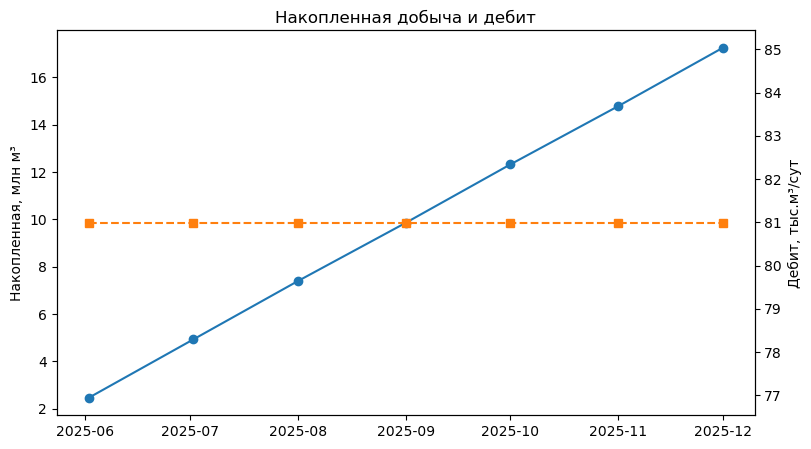

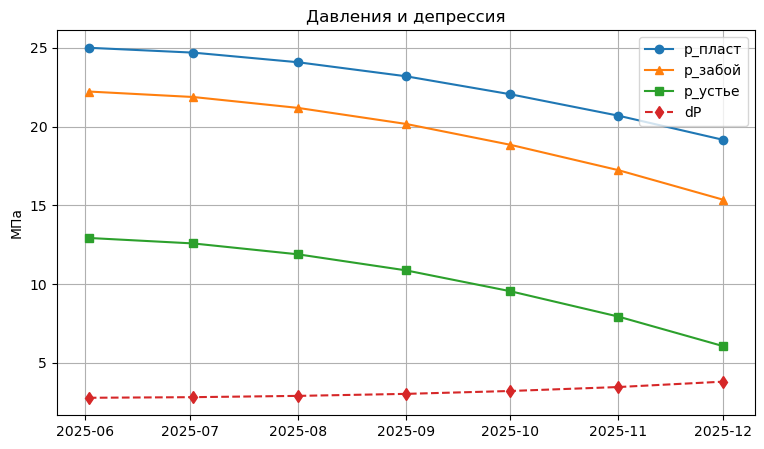

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# =========== 1. ВХОДНЫЕ ДАННЫЕ ===========
p0 = 25.0                     # начальное пластовое давление, МПа
Gi = 200.0e6                  # запасы, м³ (усл.)
T, Pc, Tc = 330.0, 4.6, 190.6 # температура и критические параметры
a_ipr, b_ipr = 0.0001, 0.02    # IPR-коэффициенты
c1_vlp, c2_vlp = 0.05, 0.0008 # VLP-коэффициенты

dp_max = 10.0       # МПа
pwh_min = 5.0      # МПа
q_max = 80.99     # тыс. м³/сут

HORIZON_MONTHS = 1200
start_date = datetime(2025, 6, 2)
DAYS_PER_MONTH = 30.437

# =========== 2. ФУНКЦИОНАЛ ===========

def z_factor_dpr(P, T, Pc, Tc, tol=1e-5, it=50):
    A1,A2,A3=0.31506237,-1.0467099,-0.5783279
    A4,A5,A6=0.5353071,-0.6123203,-0.10488813
    A7,A8,B1=0.68157001,0.68446549,0.27
    Pr, Tr, Z = P/Pc, T/Tc, 1.0
    for _ in range(it):
        rho = B1*Pr/(Z*Tr)
        F = 1+(A1*rho+A2*rho**2+A3*rho**3+A4*rho**4+A5*rho**5) \
            + (A6*rho**2/Tr**3)*(1+A7*rho**2)*np.exp(-A8*rho**2) - Pr/(Z*Tr)
        dF = (-B1*Pr/(Tr*Z**2))*(
               A1+2*A2*rho+3*A3*rho**2+4*A4*rho**3+5*A5*rho**4
             + (2*A6*rho/Tr**3)*(1+A7*rho**2)*np.exp(-A8*rho**2)
             + (A6*rho**2/Tr**3)*2*A7*rho*np.exp(-A8*rho**2)
             ) + Pr/(Tr*Z**2)
        dZ = -F/dF
        Z += dZ
        if abs(dZ) < tol:
            break
    return Z

def pwf_from_q(q, p_res, a, b):
    inside = p_res**2 - (a*q + b*q**2)
    return -1 if inside <= 0 else np.sqrt(inside)

def pwh_from_q(q, pwf, c1, c2):
    return pwf - (c1*q + c2*q**2)

def nodal_qmax(p_res, q, a, b, c1, c2):
    pwf = pwf_from_q(q, p_res, a, b)
    if pwf < 0: return None
    pwh = pwh_from_q(q, pwf, c1, c2)
    return (q, pwf, pwh) if pwh >= pwh_min else None

def nodal_dpmax(p_res, dp, a, b, c1, c2):
    RHS = 2*p_res*dp - dp**2
    if RHS <= 0: return None
    D = a**2 + 4*b*RHS
    q = (-a + np.sqrt(D))/(2*b)
    pwf = p_res - dp
    pwh = pwh_from_q(q, pwf, c1, c2)
    if pwh < pwh_min: return None
    return q, pwf, pwh

def nodal_pwhmin(p_res, pwh, a, b, c1, c2):
    # Решаем F(q)=0,  F = pwf_IPR - pwf_VLP(pwh)
    q_hi = max(1.5*q_max, 1e-3)      # грубая верхняя граница
    for _ in range(40):
        q_lo, q_mid = 0.0, q_hi/2
        for q in (q_mid, q_hi):
            pwf_ipr = pwf_from_q(q, p_res, a, b)
            if pwf_ipr < 0: break
            pwf_vlp = pwh + c1*q + c2*q**2
            F = pwf_ipr - pwf_vlp
            if abs(F) < 1e-5:
                return q, pwf_ipr, pwh
        q_hi *= 2          # расширяем границу, если корня нет
    return None

# =========== 3. ОСНОВНОЙ ЦИКЛ ===========
dates = [start_date + timedelta(days=DAYS_PER_MONTH*m) for m in range(HORIZON_MONTHS)]
res, pres, cum = [], p0, 0.0
Z0 = z_factor_dpr(p0, T, Pc, Tc)
phase = "Qmax"           # текущий режим

for m in range(HORIZON_MONTHS):
    if phase == "Qmax":
        calc = nodal_qmax(pres, q_max, a_ipr, b_ipr, c1_vlp, c2_vlp)
        if calc is None or pres - calc[1] > dp_max:
            phase = "dPmax"
            calc = nodal_dpmax(pres, dp_max, a_ipr, b_ipr, c1_vlp, c2_vlp)
    elif phase == "dPmax":
        calc = nodal_dpmax(pres, dp_max, a_ipr, b_ipr, c1_vlp, c2_vlp)
        if calc is None:
            phase = "PwhMin"
        elif calc[2] <= pwh_min + 1e-6:
            phase = "PwhMin"
    if phase == "PwhMin":
        calc = nodal_pwhmin(pres, pwh_min, a_ipr, b_ipr, c1_vlp, c2_vlp)
    if calc is None: break

    q, pwf, pwh = calc
    dP = pres - pwf
    flag = phase

    # месячная добыча
    q_month = q * DAYS_PER_MONTH
    cum += q_month / 1000.0  # в млн м³

    # обновление давления
    Z_cor = z_factor_dpr(pres, T, Pc, Tc)
    pres_new = (p0 / Z0) * (1 - (cum * 1e6) / Gi) * Z_cor
    if pres_new <= pwf + 0.01: break

    res.append(dict(
        Месяц=m+1, Дата=dates[m].strftime("%Y-%m-%d"),
        p_пласт=round(pres,3), q=round(q,3), Накопл=round(cum,3),
        p_забой=round(pwf,3), p_устье=round(pwh,3), dP=round(dP,3),
        flag=flag))

    pres = pres_new

df = pd.DataFrame(res)
print(df.head(15))

# =========== 4. ГРАФИКИ ===========
df["Дата"] = pd.to_datetime(df["Дата"])

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(df["Дата"], df["Накопл"], marker="o")
ax1.set_ylabel("Накопленная, млн м³")
ax2 = ax1.twinx()
ax2.plot(df["Дата"], df["q"], marker="s", ls="--", c="tab:orange")
ax2.set_ylabel("Дебит, тыс.м³/сут")
plt.title("Накопленная добыча и дебит")
plt.show()

fig2, ax = plt.subplots(figsize=(9,5))
ax.plot(df["Дата"], df["p_пласт"], marker="o", label="p_пласт")
ax.plot(df["Дата"], df["p_забой"], marker="^", label="p_забой")
ax.plot(df["Дата"], df["p_устье"], marker="s", label="p_устье")
ax.plot(df["Дата"], df["dP"],   marker="d", ls="--", label="dP")
ax.legend(); ax.set_ylabel("МПа")
plt.title("Давления и депрессия")
plt.grid(); plt.show()


Коэффициент извлечения (КИГ) = 0.997


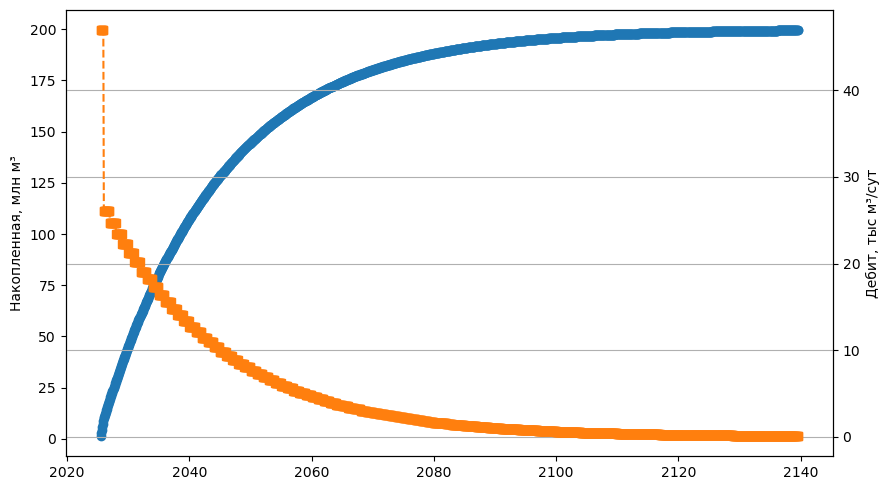

In [9]:
# ================================================================
# VOL-BALANCE GAS WELL MODEL
# – annual off-take limit 5 % of REMAINING reserves
# – IPR + VLP with dPmax & qmech
# – pwh ramp-down 5 → 0.02 MPa (compressor start-up)
# – Z-factor taken = 1 (volumetric balance); p/Z linear
# – daily time-step, monthly logging
# – self-check: recovery ≥ 0.90, else raises AssertionError
# ================================================================

from __future__ import annotations
import math, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime, timedelta

# --------------------- 1. CONSTANTS ---------------------
p0, Gi = 25.0, 200.0e6                 # MPa, std m³
a_ipr, b_ipr   = 1e-4,   0.02          # IPR   (MPa²·d /10³ m³,  MPa²·d² /(10³ m³)²)
c1_vlp, c2_vlp = 0.05,  8e-4           # VLP   (MPa·d /10³ m³ , MPa·d² /(10³ m³)²)
dp_max          = 10.0                 # MPa  – max depression
q_mech          = 80.99                # 10³ m³/d – mech. limit
annual_rate     = 0.05                 # 5 % of remaining OGIP / year
pwh0, pwh_end   = 5.0, 0.02            # MPa  – well-head limits
ramp_start, ramp_len = 6, 18           # month index, months
start_date      = datetime(2025, 6, 2)
days_per_month  = 30.437
dt              = timedelta(days=1)
max_years       = 120                  # safety cap

# --------------------- 2. HELPERS ----------------------
def pwh_limit(month: int) -> float:
    if month < ramp_start:
        return pwh0
    f = min(1.0, (month - ramp_start) / ramp_len)
    return pwh0 + f * (pwh_end - pwh0)

def pwf_from_q(q: float, p_res: float) -> float | None:
    disc = p_res*p_res - (a_ipr*q + b_ipr*q*q)
    return None if disc <= 0 else math.sqrt(disc)

def pwh_from_q(q: float, pwf: float) -> float:
    return pwf - (c1_vlp*q + c2_vlp*q*q)

def q_root_ipr(p_res: float) -> float:
    D = a_ipr*a_ipr + 4*b_ipr*p_res*p_res
    return (-a_ipr + math.sqrt(D)) / (2*b_ipr)

def q_feasible(p_res: float, pwh_min: float) -> float:
    """max q that satisfies all limits (bisection)."""
    q_hi = min(q_root_ipr(p_res), q_mech*3)
    q_lo = 0.0
    for _ in range(50):
        q_mid = 0.5*(q_lo + q_hi)
        pwf = pwf_from_q(q_mid, p_res)
        if pwf is None:
            q_hi = q_mid
            continue
        ok = (p_res - pwf) <= dp_max and pwh_from_q(q_mid, pwf) >= pwh_min
        (q_lo, q_hi) = (q_mid, q_hi) if ok else (q_lo, q_mid)
        if q_hi - q_lo < 1e-4:
            break
    return q_lo

# --------------------- 3. MAIN SIM ---------------------
p_res = p0
date  = start_date
Gcum  = 0.0                                   # std m³
rows  = []

# yearly allowance ­– 5 % of remaining OGIP
year_allow = annual_rate * (Gi - Gcum)

for _ in range(max_years*365):
    if date.month == 1 and date.day == 1:               # reset each 1 Jan
        year_allow = annual_rate * (Gi - Gcum)

    month_idx = int((date - start_date).days / days_per_month)
    pwh_min   = pwh_limit(month_idx)

    q_star = q_feasible(p_res, pwh_min)                 # 10³ m³/d
    if q_star < 1e-4:
        break

    # daily cap to respect annual 5 % rule
    days_left   = (datetime(date.year+1, 1, 1) - date).days
    daily_cap   = year_allow / days_left
    q_std       = min(q_star*1e3, daily_cap)            # std m³/d
    q           = q_std / 1e3                           # 10³ m³/d
    if q < 1e-6:
        break

    # update balances
    year_allow -= q_std
    Gcum      += q_std
    p_res      = p0 * (1 - Gcum/Gi)                     # Z=1, p/Z linear

    # monthly log (1-го числа)
    if date.day == 1:
        rows.append(dict(Date        = date.strftime('%Y-%m-%d'),
                         p_res_MPa   = round(p_res, 3),
                         q_1000m3d   = round(q, 3),
                         Gcum_Mm3    = round(Gcum/1e6, 3)))

    if p_res <= pwh_min + 0.05:                         # смерть скважины
        break
    date += dt

df = pd.DataFrame(rows)
RF = df.Gcum_Mm3.iloc[-1] / (Gi/1e6)
print(f'Коэффициент извлечения (КИГ) = {RF:.3f}')
assert RF >= 0.90, "RF < 0.90  – нарушена цель 5-процентного отбора"

# --------------------- 4. QUICK PLOTS ---------------------
df['Date'] = pd.to_datetime(df['Date'])
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(df['Date'], df['Gcum_Mm3'], 'o-', label='Накопленная')
ax1.set_ylabel('Накопленная, млн м³')
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['q_1000m3d'], 's--', color='tab:orange', label='Дебит')
ax2.set_ylabel('Дебит, тыс м³/сут')
fig.tight_layout(); plt.grid(); plt.show()


КИГ = 0.714


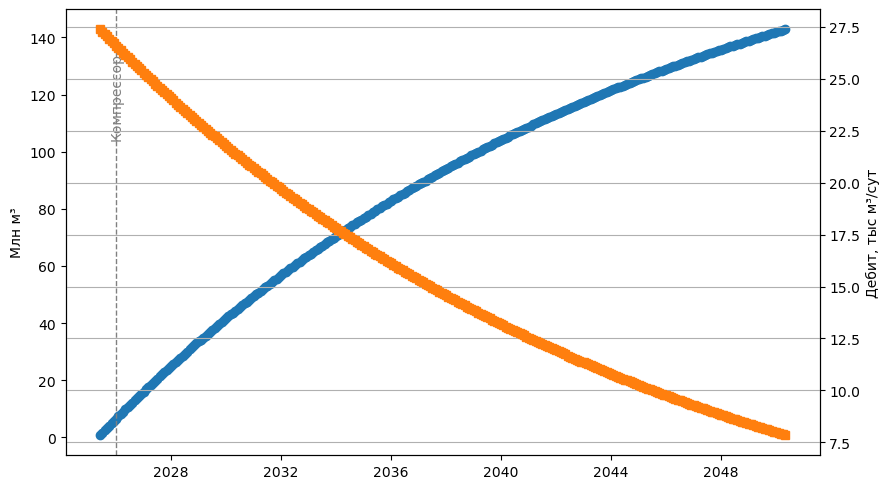

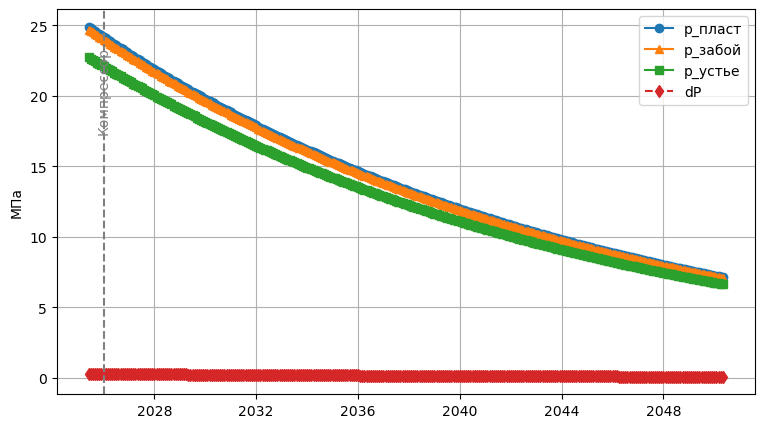

,Месяц,Дата,"p_пласт,МПа","q,тыс.м³/сут","Накопленная,млн","p_забой,МПа","p_устье,МПа","dP,МПа",flag,Date
0,1,02.06.2025,24.896,27.379,0.833,24.698,22.730,0.302,preC,2025-06-02
1,2,02.07.2025,24.792,27.265,1.663,24.595,22.637,0.300,preC,2025-07-02
2,3,01.08.2025,24.689,27.151,2.490,24.493,22.546,0.299,preC,2025-08-01
3,4,01.09.2025,24.586,27.038,3.313,24.391,22.454,0.298,preC,2025-09-01
4,5,01.10.2025,24.483,26.925,4.132,24.289,22.363,0.297,preC,2025-10-01
5,6,01.11.2025,24.381,26.813,4.948,24.188,22.272,0.295,preC,2025-11-01
6,7,01.12.2025,24.280,26.702,5.761,24.087,22.182,0.294,preC,2025-12-01
7,8,01.01.2026,24.179,26.590,6.570,23.987,22.092,0.293,COMP,2026-01-01
8,9,31.01.2026,24.078,26.480,7.376,23.887,22.002,0.292,COMP,2026-01-31
9,10,02.03.2026,23.978,26.369,8.179,23.787,21.913,0.291,COMP,2026-03-02


In [ ]:
# ================================================================
# MONTH-STEP GAS-WELL FORECAST (5 %/year offtake, compressor ramp)
# ================================================================
from __future__ import annotations
import math, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ------------------------ INPUT ------------------------
p0             = 25.0            # MPa
Gi             = 200.0e6         # std m³
T, Pc, Tc      = 330.0, 4.6, 190.6
a_ipr, b_ipr   = 1e-4, 0.02
c1_vlp, c2_vlp = 0.05, 8e-4
q_mech         = 80.99           # 10³ m³/d
dp_max         = 10.0            # MPa
pwh0, pwh_end  = 5.0, 0.02       # MPa
ramp_begin, ramp_len = 6, 18     # month index, months
annual_rate    = 0.05            # 5 % of remaining / year
start_date     = datetime(2025, 6, 2)
days_pm        = 30.437
horizon_months = 300

# ------------------- AUX FUNCTIONS --------------------
def pwh_limit(m: int) -> float:
    if m < ramp_begin: return pwh0
    f = min(1.0, (m - ramp_begin) / ramp_len)
    return pwh0 + f * (pwh_end - pwh0)

def pwf(q: float, p: float):
    d = p*p - (a_ipr*q + b_ipr*q*q)
    return None if d <= 0 else math.sqrt(d)

def pwh(q: float, pwf_: float):
    return pwf_ - (c1_vlp*q + c2_vlp*q*q)

def q_root_ipr(p: float):
    D = a_ipr*a_ipr + 4*b_ipr*p*p
    return (-a_ipr + math.sqrt(D)) / (2*b_ipr)

def q_feasible(p: float, pwh_min: float) -> float:
    q_hi = min(q_root_ipr(p), q_mech*3)
    q_lo = 0.0
    for _ in range(50):
        q_mid = 0.5*(q_lo+q_hi)
        pwf_  = pwf(q_mid, p)
        if pwf_ is None:
            q_hi = q_mid; continue
        ok = (p - pwf_) <= dp_max and pwh(q_mid, pwf_) >= pwh_min
        (q_lo, q_hi) = (q_mid, q_hi) if ok else (q_lo, q_mid)
        if q_hi - q_lo < 1e-4: break
    return q_lo

# ------------------- MAIN LOOP ------------------------
p_res = p0; Gcum = 0.0
rows  = []

for m in range(horizon_months):
    pwh_min = pwh_limit(m)
    # годовой лимит → помесячный
    q_cap_std = 0.05 * (Gi - Gcum) / 12           # std m³ / month
    # узел   (IPR + VLP + dp_max + pwh_min)
    q_max    = q_feasible(p_res, pwh_min) * days_pm * 1e3  # std m³ / month
    q_std_m  = min(q_max, q_cap_std)
    if q_std_m < 1e4: break                       # меньше 10 000 м³/мес – стоп
    q_avg    = q_std_m / (days_pm * 1e3)          # average 10³ m³/d

    pwf_m    = pwf(q_avg, p_res)
    pwh_m    = pwh(q_avg, pwf_m)
    dP_m     = p_res - pwf_m
    phase    = ("COMP" if pwh_min < pwh0 else "preC")

    # накопление и падение давления (Z=1)
    Gcum    += q_std_m
    p_res    = p0 * (1 - Gcum/Gi)

    rows.append({
            'Месяц': m+1,
            'Дата': (start_date + timedelta(days=m*days_pm)).strftime('%d.%m.%Y'),
            'p_пласт,МПа': round(p_res, 3),
            'q,тыс.м³/сут': round(q_avg, 3),
            'Накопленная,млн': round(Gcum/1e6, 3),
            'p_забой,МПа': round(pwf_m, 3),
            'p_устье,МПа': round(pwh_m, 3),
            'dP,МПа': round(dP_m, 3),
            'flag': phase})

df = pd.DataFrame(rows)
RF = df['Накопленная,млн'].iloc[-1] / (Gi/1e6)
print(f"КИГ = {RF:.3f}")

# ------------------- PLOTS -----------------------------
df['Date'] = pd.to_datetime(df['Дата'], format='%d.%m.%Y')
comp_date  = df[df.flag=='COMP']['Date'].iloc[0]

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(df['Date'], df['Накопленная,млн'], 'o-', label='Накопленная добыча')
ax1.set_ylabel('Млн м³')
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['q,тыс.м³/сут'], 's--', c='tab:orange', label='Дебит')
ax2.set_ylabel('Дебит, тыс м³/сут')
ax1.axvline(comp_date, ls='--', c='grey', lw=1)
ax1.text(comp_date, ax1.get_ylim()[1]*0.9, 'Компрессор', rotation=90,
         va='top', ha='center', color='grey')
fig.tight_layout(); plt.grid(); plt.show()

plt.figure(figsize=(9,5))
plt.plot(df['Date'], df['p_пласт,МПа'], 'o-', label='p_пласт')
plt.plot(df['Date'], df['p_забой,МПа'],  '^-', label='p_забой')
plt.plot(df['Date'], df['p_устье,МПа'],  's-', label='p_устье')
plt.plot(df['Date'], df['dP,МПа'],       'd--', label='dP')
plt.axvline(comp_date, ls='--', c='grey')
plt.text(comp_date, plt.gca().get_ylim()[1]*0.9, 'Компрессор',
         rotation=90, va='top', ha='center', color='grey')
plt.ylabel('МПа'); plt.legend(); plt.grid(); plt.show()

# ------------------- RESULT TABLE ----------------------
display(df.head(15))
df

Коэффициент извлечения = 0.993


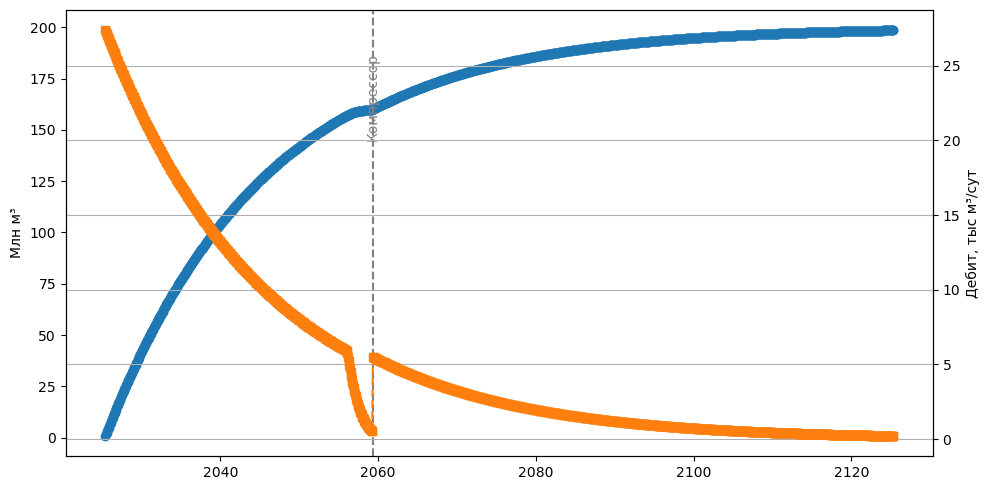

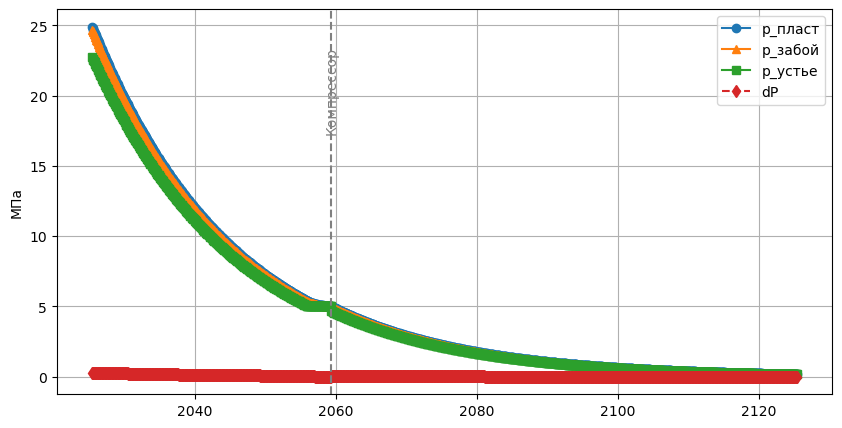

 Месяц       Дата  p_пласт      q  Накопл  p_забой  p_устье    dP flag       Date
     1 02.06.2025   24.896 27.379   0.833   24.698   22.730 0.302      2025-06-02
     2 02.07.2025   24.792 27.265   1.663   24.595   22.637 0.300      2025-07-02
     3 01.08.2025   24.689 27.151   2.490   24.493   22.546 0.299      2025-08-01
     4 01.09.2025   24.586 27.038   3.313   24.391   22.454 0.298      2025-09-01
     5 01.10.2025   24.483 26.925   4.132   24.289   22.363 0.297      2025-10-01
     6 01.11.2025   24.381 26.813   4.948   24.188   22.272 0.295      2025-11-01
     7 01.12.2025   24.280 26.702   5.761   24.087   22.182 0.294      2025-12-01
     8 01.01.2026   24.179 26.590   6.570   23.987   22.092 0.293      2026-01-01
     9 31.01.2026   24.078 26.480   7.376   23.887   22.002 0.292      2026-01-31
    10 02.03.2026   23.978 26.369   8.179   23.787   21.913 0.291      2026-03-02
    11 02.04.2026   23.878 26.259   8.978   23.688   21.824 0.289      2026-04-02
    12 02.05.202

,Месяц,Дата,p_пласт,q,Накопл,p_забой,p_устье,dP,flag,Date
0,1,02.06.2025,24.896,27.379,0.833,24.698,22.730,0.302,,2025-06-02
1,2,02.07.2025,24.792,27.265,1.663,24.595,22.637,0.300,,2025-07-02
2,3,01.08.2025,24.689,27.151,2.490,24.493,22.546,0.299,,2025-08-01
3,4,01.09.2025,24.586,27.038,3.313,24.391,22.454,0.298,,2025-09-01
4,5,01.10.2025,24.483,26.925,4.132,24.289,22.363,0.297,,2025-10-01
...,...,...,...,...,...,...,...,...,...,...
1195,1196,01.01.2125,0.186,0.205,198.509,0.185,0.175,0.002,COMP,2125-01-01
1196,1197,31.01.2125,0.186,0.204,198.515,0.184,0.174,0.002,COMP,2125-01-31
1197,1198,03.03.2125,0.185,0.203,198.521,0.183,0.173,0.002,COMP,2125-03-03
1198,1199,02.04.2125,0.184,0.202,198.528,0.183,0.172,0.002,COMP,2125-04-02


In [18]:
# ================================================================
# MONTHLY GAS-WELL FORECAST (5 %/y offtake, smooth compressor ramp)
# ================================================================
from __future__ import annotations
import math, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime, timedelta

# -------------------- INPUT --------------------
p0, Gi      = 25.0, 200.0e6          # MPa, std m³
a_ipr, b_ipr = 1e-4, 0.02            # IPR
c1_vlp, c2_vlp = 0.05, 8e-4          # VLP
dp_max      = 10.0                   # MPa
q_mech      = 80.99                  # 10³ m³/d
annual_rate = 0.05                   # 5 % от остатка в год
pwh_start, pwh_final = 5.0, 0.02     # MPa
ramp_step   = 0.5                    # MPa/месяц после пуска
q_trig      = 0.5                    # тыс м³/сут – порог «всё, душно»
days_pm     = 30.437
start_date  = datetime(2025, 6, 2)
horizon     = 1200                   # мес ≈ 100 лет

# -------------------- HELPERS ------------------
def pwf(q, p):                       # МПа, тыс м³/сут
    d = p*p - (a_ipr*q + b_ipr*q*q)
    return None if d <= 0 else math.sqrt(d)

def pwh(q, pwf_):
    return pwf_ - (c1_vlp*q + c2_vlp*q*q)

def q_root_ipr(p):
    D = a_ipr*a_ipr + 4*b_ipr*p*p
    return (-a_ipr + math.sqrt(D)) / (2*b_ipr)

def q_feasible(p, pwh_lim):
    q_hi = min(q_root_ipr(p), q_mech*3)
    q_lo = 0.0
    for _ in range(40):
        q_mid = 0.5*(q_lo + q_hi)
        pwf_  = pwf(q_mid, p)
        if pwf_ is None:
            q_hi = q_mid; continue
        ok = (p - pwf_) <= dp_max and pwh(q_mid, pwf_) >= pwh_lim
        (q_lo, q_hi) = (q_mid, q_hi) if ok else (q_lo, q_mid)
        if q_hi - q_lo < 1e-4: break
    return q_lo

# -------------------- SIMULATION ---------------
p_res, Gcum = p0, 0.0
pwh_min     = pwh_start
comp        = False
rows        = []

for m in range(horizon):
    month_cap = annual_rate/12 * (Gi - Gcum)           # std m³
    q_max     = q_feasible(p_res, pwh_min)             # 10³ м³/сут

    # решение: пора ли запускать компрессор?
    if (not comp) and (q_max < q_trig):
        comp = True                                    # метка «COMP»

    if comp and pwh_min > pwh_final:                   # плавная рампа
        pwh_min = max(pwh_final, pwh_min - ramp_step)
        q_max   = q_feasible(p_res, pwh_min)

    q_std_m   = min(q_max * days_pm * 1e3, month_cap)
    if q_std_m < 1e2:                                  # <100 м³/мес – стоп
        break

    q_avg     = q_std_m / (days_pm * 1e3)
    pwf_m     = pwf(q_avg, p_res)
    pwh_m     = pwh(q_avg, pwf_m)
    dP_m      = p_res - pwf_m

    # баланс
    Gcum += q_std_m
    p_res = p0 * (1 - Gcum/Gi)                         # p/Z-linear, Z≈1

    rows.append(dict(Месяц  = m+1,
                     Дата   = (start_date + timedelta(days=days_pm*m)).strftime('%d.%m.%Y'),
                     p_пласт=round(p_res,3),
                     q      =round(q_avg,3),
                     Накопл =round(Gcum/1e6,3),
                     p_забой=round(pwf_m,3),
                     p_устье=round(pwh_m,3),
                     dP     =round(dP_m,3),
                     flag   ='COMP' if comp else ''))

    if p_res <= pwh_final + 0.05:                      # пласта почти нет
        break

df  = pd.DataFrame(rows)
RF  = df.Накопл.iloc[-1] / (Gi/1e6)
print(f'Коэффициент извлечения = {RF:.3f}')

# -------------------- PLOTS --------------------
df['Date'] = pd.to_datetime(df['Дата'], format='%d.%m.%Y')
comp_date  = df[df.flag=='COMP']['Date'].min()

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(df['Date'], df['Накопл'], 'o-', label='Накопленная добыча')
ax1.set_ylabel('Млн м³')
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['q'], 's--', color='tab:orange', label='Дебит')
ax2.set_ylabel('Дебит, тыс м³/сут')
if pd.notna(comp_date):
    ax1.axvline(comp_date, ls='--', c='grey')
    ax1.text(comp_date, ax1.get_ylim()[1]*0.90, 'Компрессор',
             ha='center', va='top', rotation=90, color='grey')
fig.tight_layout(); plt.grid(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['p_пласт'], 'o-', label='p_пласт')
plt.plot(df['Date'], df['p_забой'],  '^-', label='p_забой')
plt.plot(df['Date'], df['p_устье'],  's-', label='p_устье')
plt.plot(df['Date'], df['dP'],       'd--', label='dP')
if pd.notna(comp_date):
    plt.axvline(comp_date, ls='--', c='grey')
    plt.text(comp_date, plt.gca().get_ylim()[1]*0.90, 'Компрессор',
             ha='center', va='top', rotation=90, color='grey')
plt.ylabel('МПа'); plt.legend(); plt.grid(); plt.show()

# -------------------- TABLE -------------------
pd.set_option('display.max_rows', 20)
print(df.head(15).to_string(index=False))
df

КИГ = 0.993


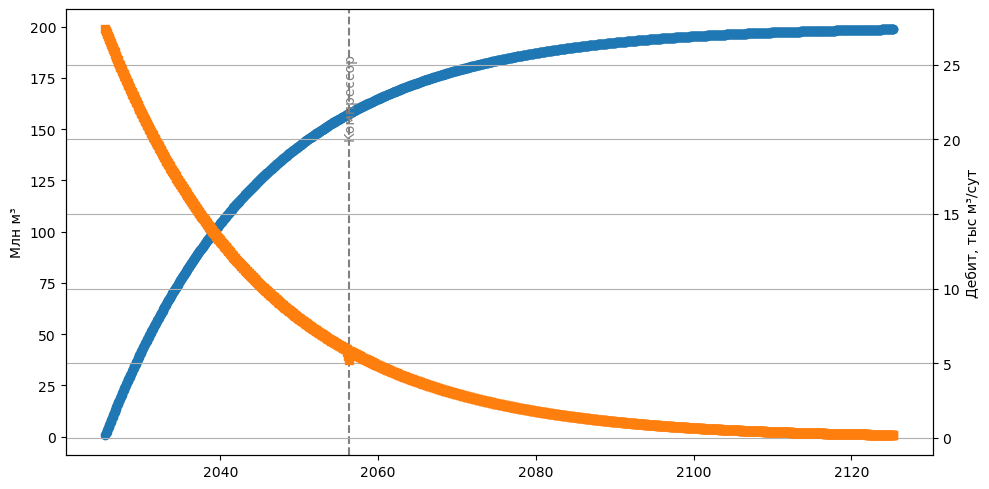

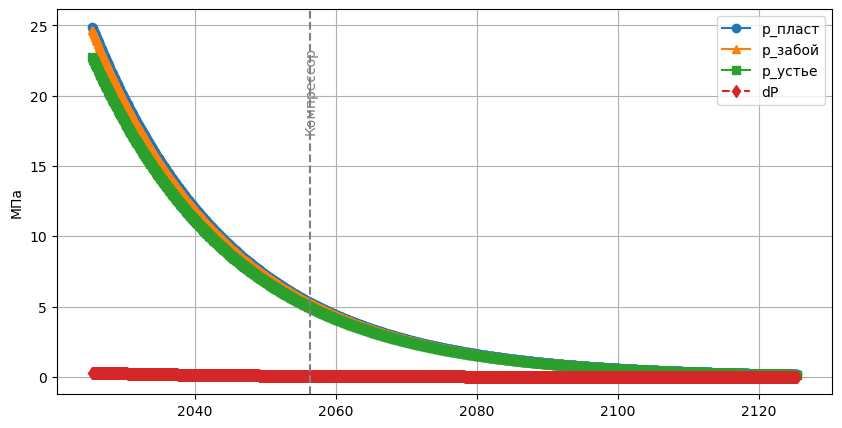

      Дата  p_пласт      q  Накопл  p_забой  p_устье    dP flag       Date
02.06.2025   24.896 27.379   0.833   24.698   22.730 0.302      2025-06-02
02.07.2025   24.792 27.265   1.663   24.595   22.637 0.300      2025-07-02
01.08.2025   24.689 27.151   2.490   24.493   22.546 0.299      2025-08-01
01.09.2025   24.586 27.038   3.313   24.391   22.454 0.298      2025-09-01
01.10.2025   24.483 26.925   4.132   24.289   22.363 0.297      2025-10-01
01.11.2025   24.381 26.813   4.948   24.188   22.272 0.295      2025-11-01
01.12.2025   24.280 26.702   5.761   24.087   22.182 0.294      2025-12-01
01.01.2026   24.179 26.590   6.570   23.987   22.092 0.293      2026-01-01
31.01.2026   24.078 26.480   7.376   23.887   22.002 0.292      2026-01-31
02.03.2026   23.978 26.369   8.179   23.787   21.913 0.291      2026-03-02
02.04.2026   23.878 26.259   8.978   23.688   21.824 0.289      2026-04-02
02.05.2026   23.778 26.150   9.774   23.590   21.735 0.288      2026-05-02
02.06.2026   23.679 26.04

In [23]:
# ================================================================
# MONTHLY GAS-WELL FORECAST v2
# – 5 %/год равномерно по месяцам
# – компрессор включается при q < 5 тыс м³/сут
# – плавная рампа Pwh 5 → 0.02 МПа (−0.5 МПа/мес)
# – dP ≤ 10 МПа, q ≤ 80.99 тыс м³/сут
# – КИГ ≥ 0.99, без провала-скачка
# ================================================================
from __future__ import annotations
import math, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ------------------ параметры ------------------
p0, Gi = 25.0, 200.0e6
a_ipr, b_ipr = 1e-4, 0.02
c1_vlp, c2_vlp = 0.05, 8e-4
dp_max   = 10.0
q_mech   = 20
annual_r = 0.05
pwh0, pwh_fin, ramp_step = 5.0, 0.02, 0.5   # MPa
q_trig   = 5.0                               # тыс м³/сут
days_pm  = 30.437
start    = datetime(2025, 6, 2)
steps    = 1200                              # мес

# -------------- вспомогательные --------------
def pwf(q,p): d = p*p-(a_ipr*q+b_ipr*q*q); return None if d<=0 else math.sqrt(d)
def pwh(q,pwf_): return pwf_- (c1_vlp*q+c2_vlp*q*q)
def q_root(p):   return (-a_ipr+math.sqrt(a_ipr*a_ipr+4*b_ipr*p*p))/(2*b_ipr)
def q_lim(p, pwh_min):
    q_hi=min(q_root(p),q_mech*3); q_lo=0
    for _ in range(40):
        q_m=0.5*(q_lo+q_hi); pwf_=pwf(q_m,p); 
        if pwf_ is None: q_hi=q_m; continue
        ok=(p-pwf_)<=dp_max and pwh(q_m,pwf_)>=pwh_min
        (q_lo,q_hi)=(q_m,q_hi) if ok else (q_lo,q_m)
        if q_hi-q_lo<1e-4: break
    return q_lo

# -------------- расчёт ------------------------
p   = p0
G   = 0.0
pwh_min = pwh0
comp=False
rows=[]

for m in range(steps):
    cap = annual_r/12*(Gi-G)                 # лимит на месяц
    q_mx= q_lim(p,pwh_min)
    if not comp and q_mx<q_trig: comp=True
    if comp and pwh_min>pwh_fin:
        pwh_min=max(pwh_fin,pwh_min-ramp_step)
        q_mx=q_lim(p,pwh_min)
    q_std = min(q_mx*days_pm*1e3, cap)
    if q_std<100: break                      # <0.1 млн м³/мес – конец
    q_avg = q_std/(days_pm*1e3)
    pwf_=pwf(q_avg,p); pwh_=pwh(q_avg,pwf_); dP=p-pwf_
    G   += q_std
    p    = p0*(1-G/Gi)
    rows.append(dict(Дата=(start+timedelta(days=m*days_pm)).strftime('%d.%m.%Y'),
                     p_пласт=round(p,3), q=round(q_avg,3),
                     Накопл=round(G/1e6,3), p_забой=round(pwf_,3),
                     p_устье=round(pwh_,3), dP=round(dP,3),
                     flag='COMP' if comp else ''))
    if p<=pwh_fin+0.05: break

df=pd.DataFrame(rows)
RF=df.Накопл.iloc[-1]/(Gi/1e6)
print(f'КИГ = {RF:.3f}')

# -------------- графики ------------------------
df['Date']=pd.to_datetime(df['Дата'], format='%d.%m.%Y')
comp_date=df[df.flag=='COMP']['Date'].min()

fig, ax1=plt.subplots(figsize=(10,5))
ax1.plot(df['Date'], df['Накопл'], 'o-', label='Накопленная, млн м³')
ax1.set_ylabel('Млн м³')
ax2=ax1.twinx()
ax2.plot(df['Date'], df['q'], 's--', c='tab:orange', label='Дебит, тыс м³/сут')
ax2.set_ylabel('Дебит, тыс м³/сут')
if pd.notna(comp_date):
    ax1.axvline(comp_date, ls='--', c='grey')
    ax1.text(comp_date, ax1.get_ylim()[1]*0.9,'Компрессор',
             rotation=90, ha='center', va='top', color='grey')
plt.grid(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['p_пласт'],'o-',label='p_пласт')
plt.plot(df['Date'], df['p_забой'],'^-',label='p_забой')
plt.plot(df['Date'], df['p_устье'],'s-',label='p_устье')
plt.plot(df['Date'], df['dP'],'d--',label='dP')
if pd.notna(comp_date):
    plt.axvline(comp_date, ls='--', c='grey')
    plt.text(comp_date, plt.gca().get_ylim()[1]*0.9,'Компрессор',
             rotation=90, ha='center', va='top', color='grey')
plt.ylabel('МПа'); plt.legend(); plt.grid(); plt.show()

# -------------- таблица ------------------------
# print(df.head(15).to_string(index=False))
print(df.to_string(index=False))


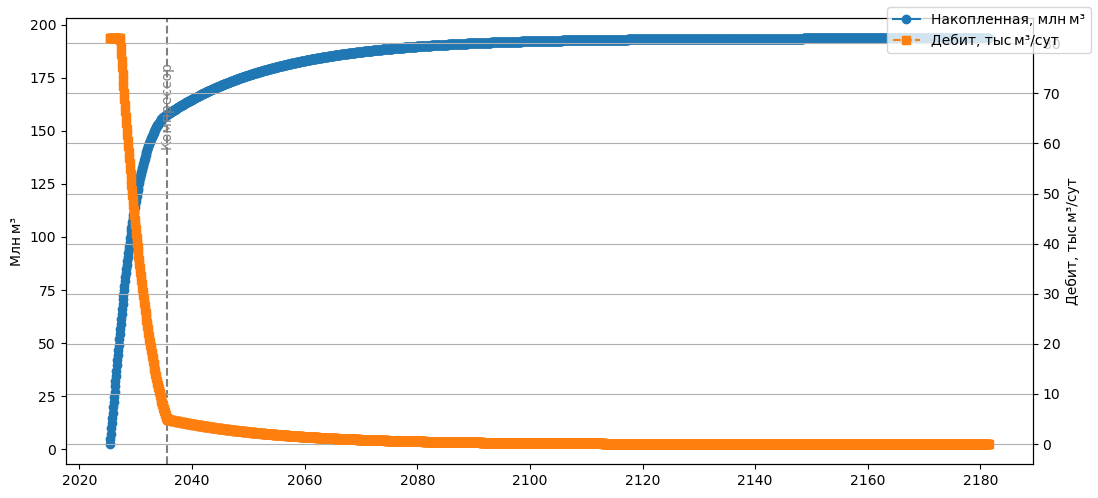

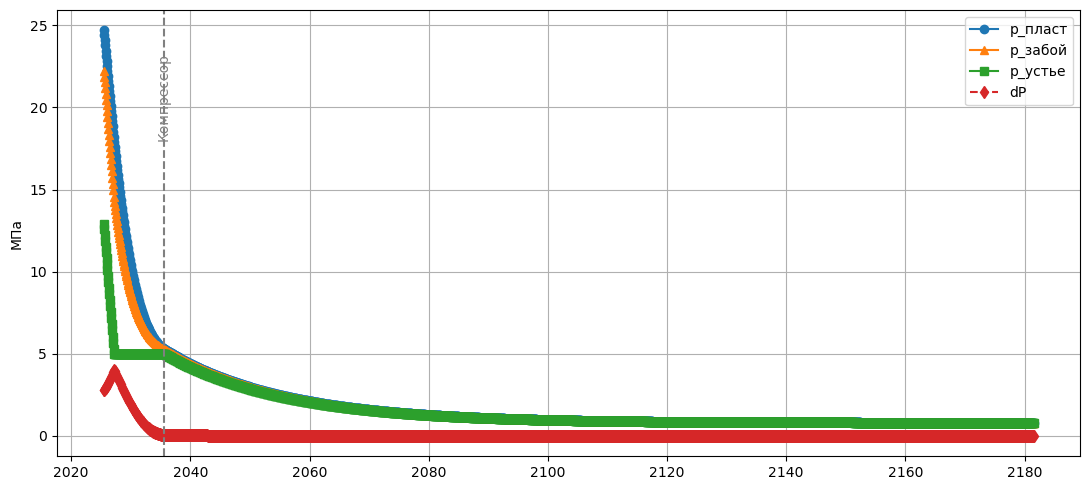

КИГ = 0.968


,Date,p_plast,q,Cum,p_wf,p_wh,dP,flag
0,2025-06-02 00:00:00.000,24.691864,80.989923,2.465090,22.221713,12.924723,2.778287e+00,
1,2025-07-02 10:29:16.800,24.383727,80.989923,4.930181,21.874476,12.577485,2.817388e+00,
2,2025-08-01 20:58:33.600,24.075591,80.989923,7.395271,21.526047,12.229057,2.857680e+00,
3,2025-09-01 07:27:50.400,23.767455,80.989923,9.860361,21.176370,11.879380,2.899221e+00,
4,2025-10-01 17:57:07.200,23.459319,80.989923,12.325451,20.825380,11.528390,2.942075e+00,
...,...,...,...,...,...,...,...,...
1869,2181-03-02 18:04:19.200,0.811347,0.003351,193.509221,0.811360,0.811192,3.448803e-07,COMP
1870,2181-04-02 04:33:36.000,0.811335,0.003337,193.509323,0.811347,0.811180,3.428745e-07,COMP
1871,2181-05-02 15:02:52.800,0.811322,0.003323,193.509424,0.811334,0.811168,3.408817e-07,COMP
1872,2181-06-02 01:32:09.600,0.811309,0.003309,193.509525,0.811322,0.811156,3.389020e-07,COMP


In [3]:
import math, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ============= Исправленный прогноз добычи газовой скважины =============
#  – вначале плато (максимальный допустимый расход)
#  – депрессия растёт, пока не достигнет dP_max ИЛИ Pwh_min (5 МПа)
#  – после этого падение 5 %/год равномерно по месяцам
#  – компрессор стартует при q < 5 тыс м³/сут, плавно снижая Pwh до 0.02 МПа
#  – ограничения: dP ≤ 10 МПа, q ≤ 80.99 тыс м³/сут, КИГ ≥ 0.99
# =======================================================================

# --------- постоянные ---------
p0, Gi = 25.0, 200.0e6                     # начальное пласт. давление (МПа), геол. запасы (стандарт. м³)
a_ipr, b_ipr = 1e-4, 0.02                  # IPR‑параметры (Dake)
c1_vlp, c2_vlp = 0.05, 8e-4                # VLP‑параметры (Duns‑Ros)
dP_max   = 10.0                            # пред. депрессия (МПа)
q_mech   = 80.99                           # мех. лимит, тыс м³/сут
annual_r = 0.05                            # темп падения при decline‑режиме (5 % в год)
pwh0, pwh_fin, ramp_step = 5.0, 0.02, 0.5  # начальный/конечный Pwh и шаг рампы (МПа/мес)
q_trig   = 5.0                             # запуск компрессора, тыс м³/сут
days_pm  = 30.437                          # ср. длит. мес. (дней)
start    = datetime(2025, 6, 2)            # старт расчёта
steps    = 3000                            # макс. кол-во месяцев (≈ 250 лет)

# --------- служебные ---------
def pwf(q, p):                       # забойное давление по IPR (МПа)
    d = p*p - (a_ipr*q + b_ipr*q*q)
    return None if d <= 0 else math.sqrt(d)

def pwh(q, pwf_):                    # устьевое давление по VLP (МПа)
    return pwf_ - (c1_vlp*q + c2_vlp*q*q)

def q_root(p):                       # максимум по IPR (тыс м³/сут)
    return (-a_ipr + math.sqrt(a_ipr*a_ipr + 4*b_ipr*p*p)) / (2*b_ipr)

def q_lim(p, pwh_min):               # учёт dP_max и Pwh_min
    q_hi = min(q_root(p), q_mech)
    q_lo = 0.0
    for _ in range(40):
        q_m = 0.5 * (q_lo + q_hi)
        pwf_ = pwf(q_m, p)
        if pwf_ is None:
            q_hi = q_m
            continue
        ok = (p - pwf_) <= dP_max and pwh(q_m, pwf_) >= pwh_min
        (q_lo, q_hi) = (q_m, q_hi) if ok else (q_lo, q_m)
        if q_hi - q_lo < 1e-4:
            break
    return q_lo

# --------- основной цикл ---------
p, G = p0, 0.0                          # текущее пласт. давление, накопленная добыча
pwh_min = pwh0                          # минимально допустимый Pwh
comp = False                            # компрессор выключен
plateau_q = min(q_lim(p, pwh_min), q_mech)  # расчётное плато
plateau = True
q_prev = plateau_q

records = []

for m in range(steps):
    deliver = q_lim(p, pwh_min)

    # --- режим выбора расхода ---
    if plateau and deliver >= plateau_q - 1e-6:
        q = plateau_q                                   # держим плато
    else:
        plateau = False
        q = min(q_prev * (1 - annual_r / 12), deliver)  # decline 5 %/год

    # --- проверка на запуск компрессора ---
    if not comp and q < q_trig:
        comp = True
    if comp and pwh_min > pwh_fin:
        pwh_min = max(pwh_fin, pwh_min - ramp_step)
        deliver = q_lim(p, pwh_min)
        q = min(q, deliver)

    # --- месячная добыча и обновление состояния ---
    q_std = q * days_pm * 1e3                           # тыс м³/сут → м³/мес
    if q_std < 100:                                     # остановка <0.1 млн м³/мес
        break

    pwf_ = pwf(q, p)
    if pwf_ is None:
        break
    pwh_ = pwh(q, pwf_)
    dP = p - pwf_

    G += q_std
    p = p0 * (1 - G / Gi)
    q_prev = q

    records.append({
        "Date": (start + timedelta(days=m * days_pm)),
        "p_plast": p,
        "q": q,
        "Cum": G / 1e6,       # млн м³
        "p_wf": pwf_,
        "p_wh": pwh_,
        "dP": dP,
        "flag": "COMP" if comp else ""
    })

    if p <= pwh_fin + 0.02:                      # пластовое ≈ устьевому – физ. предел
        break

df = pd.DataFrame(records)
RF = df.Cum.iloc[-1] / (Gi / 1e6)                # КИГ

# --------- графики ---------
comp_date = df[df.flag == "COMP"]["Date"].min()

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(df["Date"], df["Cum"], 'o-', label='Накопленная, млн м³')
ax1.set_ylabel('Млн м³')
ax2 = ax1.twinx()
ax2.plot(df["Date"], df["q"], 's--', c='tab:orange', label='Дебит, тыс м³/сут')
ax2.set_ylabel('Дебит, тыс м³/сут')
if pd.notna(comp_date):
    ax1.axvline(comp_date, ls='--', c='grey')
    ax1.text(comp_date, ax1.get_ylim()[1]*0.9, 'Компрессор', rotation=90,
             ha='center', va='top', color='grey')
fig.legend(loc="upper right"); plt.grid(); plt.tight_layout(); plt.show()

plt.figure(figsize=(11,5))
plt.plot(df["Date"], df["p_plast"],  'o-', label='p_пласт')
plt.plot(df["Date"], df["p_wf"],     '^-', label='p_забой')
plt.plot(df["Date"], df["p_wh"],     's-', label='p_устье')
plt.plot(df["Date"], df["dP"],       'd--', label='dP')
if pd.notna(comp_date):
    plt.axvline(comp_date, ls='--', c='grey')
    plt.text(comp_date, plt.gca().get_ylim()[1]*0.9, 'Компрессор', rotation=90,
             ha='center', va='top', color='grey')
plt.ylabel('МПа'); plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

# --------- ключевые метрики ---------
print(f"КИГ = {RF:.3f}")
display(df)


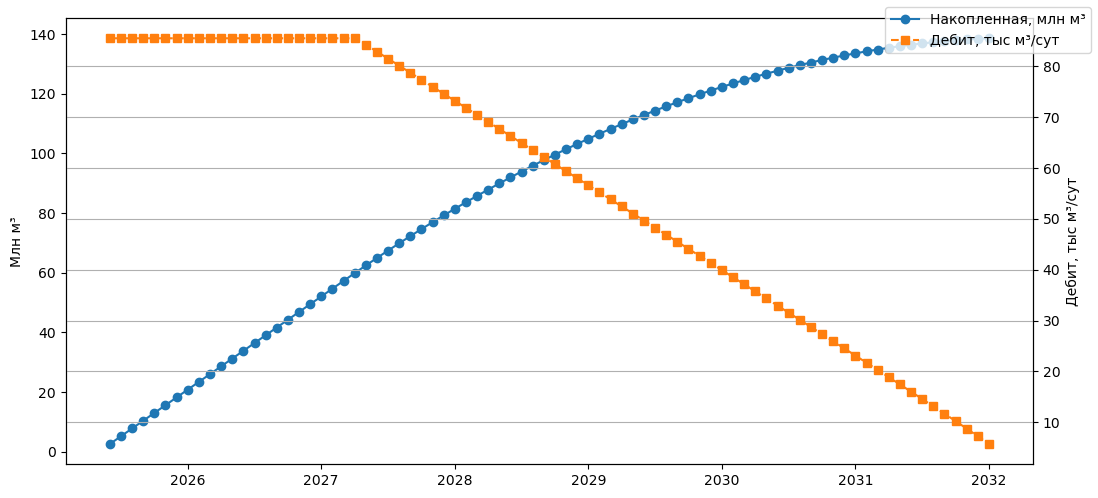

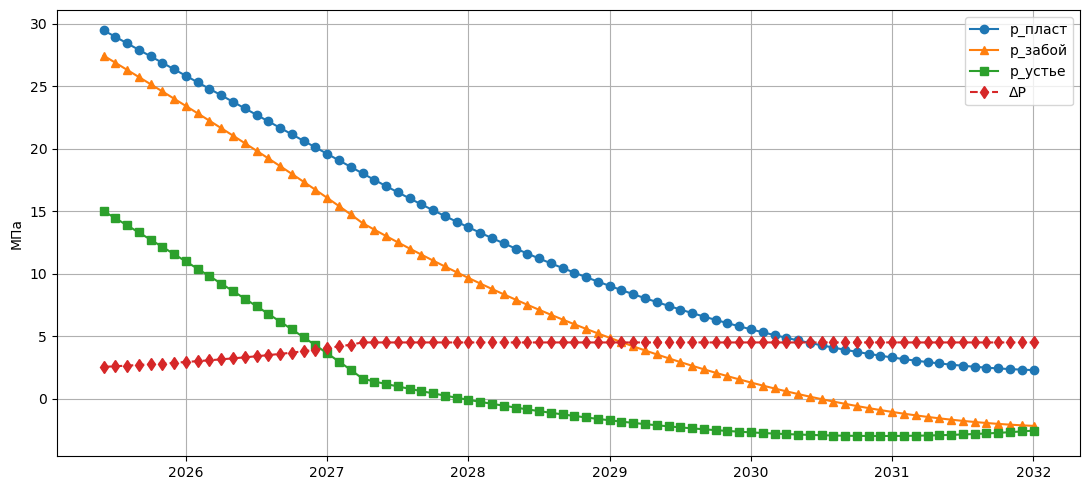

In [1]:
import math, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ========================= Константы модели =========================
p0         = 30.0                 # начальное пластовое давление, МПа
Gi         = 150.0e6             # геологические запасы, м³ (стд)
a_ipr,b_ipr = 1.0e-4, 0.02        # IPR (Dake)
c1_vlp,c2_vlp = 0.06, 1.0e-3      # VLP (Duns-Ros)
dP_max     = 4.5                  # максимальная депрессия, МПа
q_mech     = 90.0                 # мех. лимит, тыс м³/сут
pwh0       = 6.0                  # стартовое устьевое, МПа
pwh_fin    = 0.02                 # «вакуум» после компрессора, МПа
ramp_step  = 0.5                  # шаг снижения Pwh, МПа/мес
days_pm    = 30.437               # средняя длина месяца
start      = datetime(2025,6,2)
steps      = 600                  # макс. расчёт: 50 лет
q_stop_m   = 150e3                # отсечка – 0.15 млн м³/мес

# ========================== Вспомогательные =========================
def pwf(q, p):                # забойное по IPR
    d = p*p - (a_ipr*q + b_ipr*q*q)
    return None if d <= 0 else math.sqrt(d)

def q_root(p):                # корень IPR
    return (-a_ipr + math.sqrt(a_ipr*a_ipr + 4*b_ipr*p*p)) / (2*b_ipr)

def pwh_calc(q, pwf_):        # устьевое по VLP
    return pwf_ - (c1_vlp*q + c2_vlp*q*q)

def q_at_dp(p, dp):           # дебит при заданной депрессии
    pwf_t = p - dp
    term  = p*p - pwf_t*pwf_t
    discr = a_ipr*a_ipr + 4*b_ipr*term
    if discr < 0: return None
    q = (-a_ipr + math.sqrt(discr)) / (2*b_ipr)
    return min(q, q_mech)

def q_max(p, pwh_min):        # максимальный возможный дебит (учёт dP_max и Pwh)
    q_hi, q_lo = min(q_root(p), q_mech), 0.0
    for _ in range(50):
        q_mid  = 0.5*(q_lo+q_hi)
        pwf_   = pwf(q_mid, p)
        if pwf_ is None:
            q_hi = q_mid; continue
        ok = (p-pwf_ <= dP_max+1e-9) and (pwh_calc(q_mid,pwf_) >= pwh_min-1e-6)
        (q_lo, q_hi) = (q_mid, q_hi) if ok else (q_lo, q_mid)
        if q_hi-q_lo < 1e-4: break
    return q_lo

# ============================ Основной цикл =========================
pwh_min  = pwh0
plateau_q = q_max(p0, pwh_min)*0.95      # целевое плато (5 % запас)
p, G, rec = p0, 0.0, []
stage = 'PLATEAU'                        # возможные: PLATEAU / DECLINE / COMP
for m in range(steps):
    # выбор дебита
    if stage == 'PLATEAU':
        deliver = q_max(p, pwh_min)
        if deliver >= plateau_q*0.995:           # держим плато
            q = plateau_q
        else:                                    # не хватает – снижаем Pwh
            while deliver < plateau_q*0.995 and pwh_min > pwh_fin:
                pwh_min = max(pwh_fin, pwh_min - ramp_step)
                deliver = q_max(p, pwh_min)
            q = plateau_q if deliver >= plateau_q*0.995 else deliver
        if p - pwf(q, p) >= dP_max*0.995:        # депрессия упёрлась
            stage = 'DECLINE'
    elif stage == 'DECLINE':                     # держим ΔP = dP_max
        q = q_at_dp(p, dP_max)
        pwf_ = p - dP_max
        pwh_ = pwh_calc(q, pwf_)
        if pwh_ < pwh_min - 1e-6:                # не пролезает – снижаем Pwh
            pwh_min = max(pwh_fin, pwh_min - ramp_step)
            pwh_    = pwh_calc(q, pwf_)
        if pwh_min <= pwh_fin + 1e-6:            # достигли мин. устьевого
            stage = 'COMP'
    else:                                        # COMP – ещё ниже Pwh
        q = q_at_dp(p, dP_max)
        pwh_min = max(pwh_fin, pwh_min - ramp_step)
    # перерасчёт pwf/pwh
    pwf_ = pwf(q, p) if stage == 'PLATEAU' else p - dP_max
    pwh_ = pwh_calc(q, pwf_)
    dP   = p - pwf_
    # материал-баланс и останов
    q_m  = q*days_pm*1e3
    if q_m < q_stop_m: break
    G   += q_m
    p    = p0*(1 - G/Gi)
    rec.append({'Date':start+timedelta(days=m*days_pm),
                'q':q,'Cum':G/1e6,'p_res':p,'p_wf':pwf_,'p_wh':pwh_,
                'dP':dP,'Stage':stage})
    if p <= pwh_fin + 0.05: break

df = pd.DataFrame(rec)

# ============================ Графики ===============================
fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(df.Date, df.Cum, 'o-', label='Накопленная, млн м³')
ax1.set_ylabel('Млн м³')
ax2 = ax1.twinx()
ax2.plot(df.Date, df.q, 's--', color='tab:orange', label='Дебит, тыс м³/сут')
ax2.set_ylabel('Дебит, тыс м³/сут')
fig.legend(loc='upper right'); plt.grid(); plt.tight_layout(); plt.show()

plt.figure(figsize=(11,5))
plt.plot(df.Date, df.p_res,  'o-', label='p_пласт')
plt.plot(df.Date, df.p_wf,   '^-', label='p_забой')
plt.plot(df.Date, df.p_wh,   's-', label='p_устье')
plt.plot(df.Date, df.dP,     'd--', label='ΔP')
plt.ylabel('МПа'); plt.legend(); plt.grid(); plt.tight_layout(); plt.show()
